
<h1 id="Preference-Guided-Constraint-Relaxation-for-Infeasible-Design-Decisions">Preference-Guided Constraint Relaxation for Infeasible Design Decisions<a class="anchor-link" href="#Preference-Guided-Constraint-Relaxation-for-Infeasible-Design-Decisions">¶</a></h1><p><em>An illustrative example: selecting a vessel design when no option satisfies every requirement.</em></p>
<p>Constrained design and procurement decisions occasionally have <strong>no feasible solution</strong> — every available option
violates at least one hard requirement. Conventional optimisation tools handle this case poorly: they return
nothing, and give no indication of <em>which</em> requirement is binding or <em>how far</em> it would have to move to admit a
solution. That judgement is then left to manual, ad-hoc negotiation.</p>
<p>This notebook demonstrates an alternative. Using <strong>IGS-GA-II</strong>: the preference-guided optimiser, a hard
acceptability limit is modelled as a <em>preference</em> rather than a hard constraint. When the
problem is infeasible, the method identifies the <strong>smallest, most acceptable relaxation</strong> that restores
feasibility and reports it as a concrete recommendation.</p>
<p><strong>The example.</strong> A vessel design is assembled from three choices: <strong>engine</strong> (A, B, or C), <strong>hull material</strong>
(steel or composite), and <strong>lifeboat count</strong> (2–6), each trading cost against safety. Two requirements are fixed
in advance:</p>
<ul>
<li><strong>Budget:</strong> total cost must not exceed <strong>1000</strong>.</li>
<li><strong>Safety:</strong> the design must achieve a safety rating of at least <strong>85%</strong> to be certified for service.</li>
</ul>
<p>No design satisfies both. The sections below show how the method converts this dead end into a clear
recommendation: <em>increase the budget by 5% to restore feasibility, and adopt the design that achieves it.</em></p>


In [1]:
import sys
from pathlib import Path

for _cand in (Path.cwd() / "src", Path.cwd().parent / "src"):
    if (_cand / "optimization").exists() and str(_cand) not in sys.path:
        sys.path.insert(0, str(_cand))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.core.problem import Problem
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.termination import get_termination
from pymoo.algorithms.moo.nsga2 import NSGA2

from optimization.igs_ga import IGSGA
from utils.imap_helpers import compute_imap_scores, make_pref_cv

SEED = 1
np.random.seed(SEED)

NAVY, ORANGE, PURPLE, GREEN, RED = "#11294e", "#e67e22", "#8e44ad", "#27ae60", "#e74c3c"
plt.rcParams["figure.facecolor"] = "white"



<h2 id="The-design-space">The design space<a class="anchor-link" href="#The-design-space">¶</a></h2><p>Each design combines one engine, one hull, and a lifeboat count. Cost and safety are additive over the chosen
components, so the full space contains only <strong>30 candidate designs</strong> — small enough to enumerate exhaustively and
to independently audit every claim made below.</p>


In [2]:
# Each component contributes (cost, safety-rating-points).
ENGINES = {"A": (300, 24), "B": (400, 30), "C": (500, 34)}
HULLS   = {"Steel": (250, 18), "Composite": (450, 33)}
BOATS   = [2, 3, 4, 5, 6]

COST_CAP   = 1000.0   # budget limit            (the acceptability limit to be relaxed)
SAFETY_MIN = 85.0     # safety requirement (%)  (certification threshold: remains hard constraint)

def make_ship(engine, hull, n_boats):
    """Return (total cost, total safety %) for a single design."""
    cost   = ENGINES[engine][0] + HULLS[hull][0] + 50 * n_boats
    safety = ENGINES[engine][1] + HULLS[hull][1] +  5 * n_boats
    return cost, safety

# Enumerate the full design space (3 x 2 x 5 = 30 designs).
rows = []
for e in ENGINES:
    for h in HULLS:
        for n in BOATS:
            c, s = make_ship(e, h, n)
            rows.append(dict(engine=e, hull=h, lifeboats=n, cost=c, safety=s))
ships = pd.DataFrame(rows)

COST_LO, COST_HI = float(ships.cost.min()), float(ships.cost.max())
SAFE_LO, SAFE_HI = float(ships.safety.min()), float(ships.safety.max())
print(f"{len(ships)} candidate designs")
print(f"cost range {COST_LO:.0f}-{COST_HI:.0f};  safety range {SAFE_LO:.0f}%-{SAFE_HI:.0f}%")

# Helper used by the optimisers: map a 3-number decision vector to a concrete design.
E_KEYS, H_KEYS = list(ENGINES), list(HULLS)
def decode(x):
    e = E_KEYS[int(np.clip(np.floor(x[0]), 0, len(E_KEYS) - 1))]
    h = H_KEYS[int(np.clip(np.floor(x[1]), 0, len(H_KEYS) - 1))]
    n = int(np.clip(np.round(x[2]), 2, 6))
    return e, h, n

ships.head()


30 candidate designs
cost range 650-1250;  safety range 52%-97%


,engine,hull,lifeboats,cost,safety
0,A,Steel,2,650,52
1,A,Steel,3,700,57
2,A,Steel,4,750,62
3,A,Steel,5,800,67
4,A,Steel,6,850,72



<h2 id="Step-1-%E2%80%94-Establish-that-the-problem-is-infeasible">Step 1 — Establish that the problem is infeasible<a class="anchor-link" href="#Step-1-%E2%80%94-Establish-that-the-problem-is-infeasible">¶</a></h2><p>Under the original requirements both limits are hard: a design qualifies only if it costs at most 1000 <strong>and</strong>
achieves at least 85% safety. We confirm infeasibility two independent ways — exhaustive enumeration of all 30
designs, and a standard constrained optimiser (NSGA-II). Both reach the same conclusion: <strong>no qualifying design
exists.</strong></p>


In [3]:
ships["within_budget"] = ships.cost   <= COST_CAP
ships["certifiable"]   = ships.safety >= SAFETY_MIN
ships["feasible"]      = ships.within_budget & ships.certifiable

print(f"Designs satisfying BOTH requirements (cost <= {COST_CAP:.0f} and safety >= {SAFETY_MIN:.0f}%): "
      f"{int(ships.feasible.sum())}")
print(f"  Highest safety attainable within budget : {ships[ships.within_budget].safety.max():.0f}%  "
      f"(requirement: {SAFETY_MIN:.0f}%)")
print(f"  Lowest cost meeting the safety requirement: {ships[ships.certifiable].cost.min():.0f}  "
      f"(budget limit: {COST_CAP:.0f})")


Designs satisfying BOTH requirements (cost <= 1000 and safety >= 85%): 0
  Highest safety attainable within budget : 82%  (requirement: 85%)
  Lowest cost meeting the safety requirement: 1050  (budget limit: 1000)


In [4]:
# Cross-check with a standard constrained optimiser: both limits enforced as hard constraints.
class HardShip(Problem):
    """Both limits hard: a design is feasible only if cost <= cap AND safety >= 85%."""
    def __init__(self):
        super().__init__(n_var=3, n_obj=2, n_constr=2,
                         xl=np.array([0.0, 0.0, 2.0]), xu=np.array([2.999, 1.999, 6.0]))
    def _evaluate(self, X, out, *a, **k):
        F, G = [], []
        for x in X:
            e, h, n = decode(x); c, s = make_ship(e, h, n)
            F.append([c, 100.0 - s])                       # minimise cost, minimise un-safety
            G.append([c - COST_CAP, SAFETY_MIN - s])       # both <= 0 required
        out["F"] = np.array(F); out["G"] = np.array(G)

res_std = pymoo_minimize(HardShip(), NSGA2(pop_size=40),
                         get_termination("n_gen", 100), seed=SEED, verbose=False)

X = res_std.pop.get("X")
out = HardShip().evaluate(X, return_as_dictionary=True)
cv = np.sum(np.maximum(0.0, out["G"]), axis=1)
print(f"NSGA-II final population: {int((cv <= 1e-9).sum())} feasible of {len(X)}")
print("Standard constrained optimisation returns no feasible design, and no guidance on how to proceed.")


NSGA-II final population: 0 feasible of 40
Standard constrained optimisation returns no feasible design, and no guidance on how to proceed.



<p><strong>Figure 1.</strong> Each point is one candidate design. The shaded area marks the only acceptable region — within
budget <em>and</em> meeting the safety requirement. It is empty: every design that satisfies the safety requirement
(orange) exceeds the budget, and every affordable design (left of the limit) falls short on safety.</p>


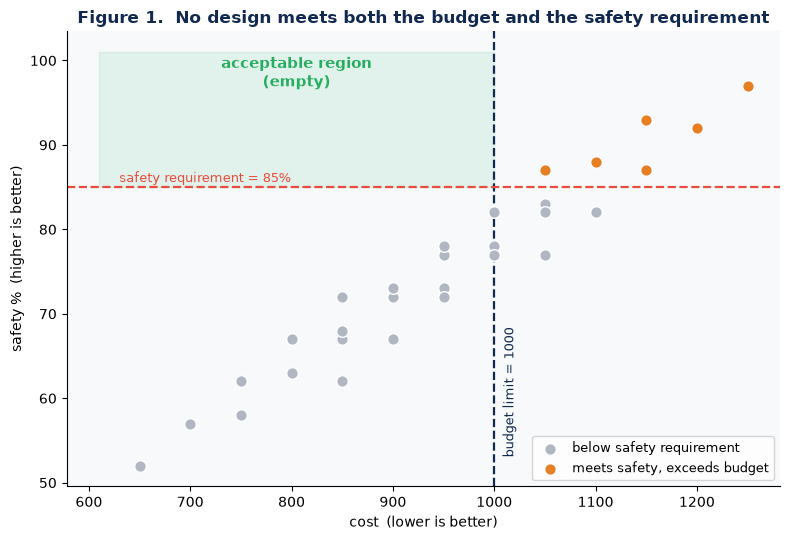

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
cert  = ships[ships.certifiable]
ncert = ships[~ships.certifiable]
ax.scatter(ncert.cost, ncert.safety, s=70, color="#b0b7c3", edgecolors="white",
           label="below safety requirement", zorder=3)
ax.scatter(cert.cost,  cert.safety,  s=70, color=ORANGE,   edgecolors="white",
           label="meets safety, exceeds budget", zorder=3)

# The (empty) acceptable region: cost <= cap AND safety >= requirement.
ax.add_patch(plt.Rectangle((COST_LO - 40, SAFETY_MIN), COST_CAP - (COST_LO - 40),
                           SAFE_HI + 4 - SAFETY_MIN, color=GREEN, alpha=0.10, zorder=1))
ax.axvline(COST_CAP, color=NAVY, ls="--", lw=1.6)
ax.axhline(SAFETY_MIN, color=RED, ls="--", lw=1.6)
ax.text(COST_CAP + 8, SAFE_LO + 1, "budget limit = 1000", color=NAVY, fontsize=9, rotation=90, va="bottom")
ax.text(COST_LO - 20, SAFETY_MIN + 0.6, "safety requirement = 85%", color=RED, fontsize=9)
ax.text((COST_LO + COST_CAP) / 2 - 20, SAFE_HI + 1.5, "acceptable region\n(empty)",
        color=GREEN, fontsize=11, ha="center", va="center", fontweight="bold")

ax.set_xlabel("cost  (lower is better)"); ax.set_ylabel("safety %  (higher is better)")
ax.set_title("Figure 1.  No design meets both the budget and the safety requirement",
             fontweight="bold", color=NAVY)
ax.legend(loc="lower right", fontsize=9); ax.set_facecolor("#f7f9fb")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()



<h2 id="Step-2-%E2%80%94-Reframe-the-budget-as-a-preference">Step 2 — Reframe the budget as a preference<a class="anchor-link" href="#Step-2-%E2%80%94-Reframe-the-budget-as-a-preference">¶</a></h2><p>The key step is to stop treating the budget as an absolute wall and instead represent it as a <strong>graded
acceptability preference</strong>. Remaining within budget is strongly preferred; exceeding it is penalised sharply —
but is never ruled out entirely. The resulting curve is high and flat below 1000, falls steeply once the budget
is breached, and yet remains strictly positive.</p>
<p>That residual signal is what makes the method work: because the score never collapses to zero, the search retains
a usable gradient even when every candidate exceeds the budget, and is drawn toward the <em>smallest</em> breach.</p>
<p>Two stakeholders are represented explicitly — one concerned solely with cost, the other solely with safety. The
85% safety requirement remains a genuine hard constraint; only the budget becomes negotiable.</p>


In [6]:
# Objective-value bounds (the optimiser operates on cost and "un-safety" = 100 - safety).
UNSAFE_LO, UNSAFE_HI = 100.0 - SAFE_HI, 100.0 - SAFE_LO     # 3, 48

# --- Stakeholder 1: cost only (lower cost preferred) ---
def pref_cost(c):
    return float(np.clip((COST_HI - c) / (COST_HI - COST_LO), 0.0, 1.0) * 100.0)

# --- Stakeholder 2: safety only (higher safety preferred) ---
def pref_unsafety(u):                       # u = 100 - safety
    return float(np.clip((UNSAFE_HI - u) / (UNSAFE_HI - UNSAFE_LO), 0.0, 1.0) * 100.0)

# --- Graded budget-acceptability preference on cost ---
#  cost <= cap : high and nearly flat (100 -> 95); being well under budget adds little
#  cost >  cap : sharp drop, with a strictly positive tail that decays toward (but never reaches) 0
def pref_budget(c, k=18.0, p=1.2):
    if c <= COST_CAP:
        return 100.0 - 5.0 * (c - COST_LO) / (COST_CAP - COST_LO)
    over = (c - COST_CAP) / COST_CAP
    return float(95.0 / (1.0 + k * (over ** p)))

# Assemble the three structures IGS-GA-II expects (cf. das-cmop.ipynb / build_imap_config).
obj_names = ["cost", "unsafety"]
preference_functions = {
    1: {"cost": pref_cost,        "unsafety": lambda u: 0.0},   # cost-only stakeholder
    2: {"cost": lambda c: 0.0,    "unsafety": pref_unsafety},   # safety-only stakeholder
    3: {"cost": pref_budget,      "unsafety": lambda u: 0.0},   # budget-acceptability preference
}
objective_weights = {
    1: {"cost": 1.0, "unsafety": 0.0},
    2: {"cost": 0.0, "unsafety": 1.0},
    3: {"cost": 1.0, "unsafety": 0.0},
}
stakeholder_weights = [0.4, 0.4, 0.2]        # cost / safety / budget-acceptability
cv_pref_fn = make_pref_cv()                  # feasibility steering for the hard safety requirement
print("Preference model configured: two stakeholders (cost, safety) plus a graded budget preference.")


Preference model configured: two stakeholders (cost, safety) plus a graded budget preference.



<p><strong>Figure 2.</strong> The two stakeholder preference functions. One values lower cost, the other values higher safety;
each is indifferent to the other's dimension.</p>


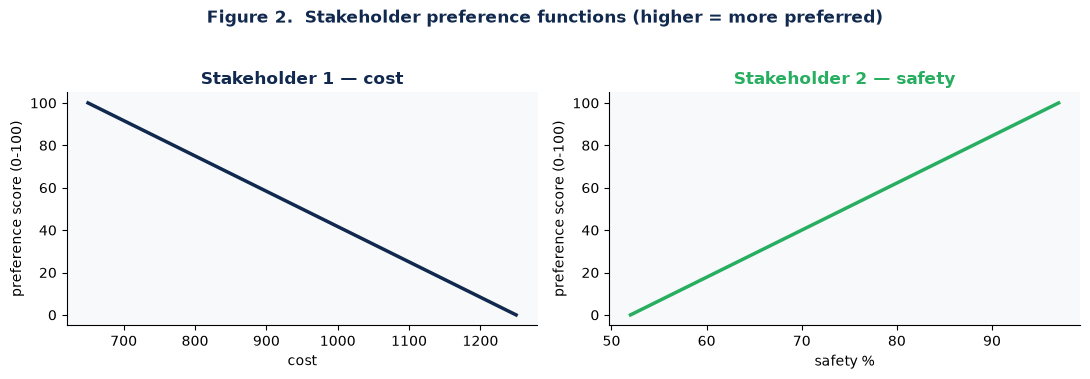

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
cs = np.linspace(COST_LO, COST_HI, 200)
axes[0].plot(cs, [pref_cost(c) for c in cs], color=NAVY, lw=2.5)
axes[0].set_title("Stakeholder 1 — cost", fontweight="bold", color=NAVY)
axes[0].set_xlabel("cost"); axes[0].set_ylabel("preference score (0-100)")

ss = np.linspace(SAFE_LO, SAFE_HI, 200)
axes[1].plot(ss, [pref_unsafety(100 - s) for s in ss], color=GREEN, lw=2.5)
axes[1].set_title("Stakeholder 2 — safety", fontweight="bold", color=GREEN)
axes[1].set_xlabel("safety %"); axes[1].set_ylabel("preference score (0-100)")

for ax in axes:
    ax.set_ylim(-5, 105); ax.set_facecolor("#f7f9fb")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Figure 2.  Stakeholder preference functions (higher = more preferred)",
             fontweight="bold", color=NAVY, y=1.04)
plt.tight_layout(); plt.show()



<p><strong>Figure 3.</strong> The budget modelled as a graded preference rather than a hard limit. Below 1000 the score is high
and nearly flat; above it the score falls sharply but remains positive, preserving the gradient that guides the
search toward the minimal acceptable overrun.</p>


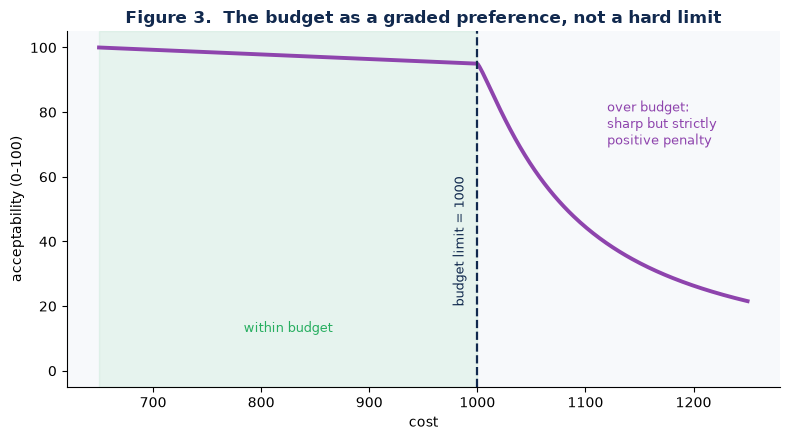

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
cs = np.linspace(COST_LO, COST_HI, 400)
ax.plot(cs, [pref_budget(c) for c in cs], color=PURPLE, lw=2.8)
ax.axvline(COST_CAP, color=NAVY, ls="--", lw=1.6)
ax.text(COST_CAP - 10, 40, "budget limit = 1000", color=NAVY, rotation=90, va="center", ha="right", fontsize=9)
ax.axvspan(COST_LO, COST_CAP, color=GREEN, alpha=0.08)
ax.text((COST_LO + COST_CAP) / 2, 12, "within budget", color=GREEN, ha="center", fontsize=9)
ax.text(COST_CAP + 120, 70, "over budget:\nsharp but strictly\npositive penalty", color=PURPLE, fontsize=9)
ax.set_xlabel("cost"); ax.set_ylabel("acceptability (0-100)")
ax.set_title("Figure 3.  The budget as a graded preference, not a hard limit",
             fontweight="bold", color=NAVY)
ax.set_ylim(-5, 105); ax.set_facecolor("#f7f9fb")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()



<h2 id="Step-3-%E2%80%94-Apply-IGS-GA-II">Step 3 — Apply IGS-GA-II<a class="anchor-link" href="#Step-3-%E2%80%94-Apply-IGS-GA-II">¶</a></h2><p>IGS-GA-II is run on the reframed problem. The safety requirement remains hard; the budget is supplied as the
preference defined above. The optimiser converges on the single design that best satisfies the stakeholders given
that the budget must be relaxed.</p>


In [9]:
class ShipDecision(Problem):
    """Safety requirement (>= 85%) remains hard; the budget is now a preference, not a constraint."""
    def __init__(self):
        super().__init__(n_var=3, n_obj=2, n_constr=1,
                         xl=np.array([0.0, 0.0, 2.0]), xu=np.array([2.999, 1.999, 6.0]))
    def _evaluate(self, X, out, *a, **k):
        F, G = [], []
        for x in X:
            e, h, n = decode(x); c, s = make_ship(e, h, n)
            F.append([c, 100.0 - s])           # cost, un-safety
            G.append([SAFETY_MIN - s])         # only the hard safety requirement remains
        out["F"] = np.array(F); out["G"] = np.array(G)

algorithm = IGSGA(
    preference_functions=preference_functions,
    objective_weights=objective_weights,
    stakeholder_weights=stakeholder_weights,
    all_objectives=obj_names,
    pop_size=40,
    tournament_selection=True,
    archive=True,
    cv_pref_fn=cv_pref_fn,     # steers toward the hard safety requirement
    cv_weight=0.5,
    seed=SEED,
    verbose=False,
)
res = pymoo_minimize(ShipDecision(), algorithm, get_termination("n_gen", 200),
                     seed=SEED, verbose=False, copy_algorithm=False)

best = res.algorithm.current_best
e_b, h_b, n_b = decode(best.get("X").flatten())
best_cost, best_safety = make_ship(e_b, h_b, n_b)
print(f"IGS-GA-II selected:  engine {e_b},  {h_b} hull,  {n_b} lifeboats")
print(f"   cost   = {best_cost:.0f}")
print(f"   safety = {best_safety:.0f}%   (certifiable: {best_safety >= SAFETY_MIN})")


IGS-GA-II selected:  engine A,  Composite hull,  6 lifeboats
   cost   = 1050
   safety = 87%   (certifiable: True)



<h2 id="Step-4-%E2%80%94-Read-off-the-recommendation">Step 4 — Read off the recommendation<a class="anchor-link" href="#Step-4-%E2%80%94-Read-off-the-recommendation">¶</a></h2><p>The selected design lies just beyond the budget. The gap between its cost and the original limit is the
recommendation: relax the budget by that margin to restore feasibility. As a check, all 30 designs are scored
directly to confirm this is the optimal certifiable design.</p>


In [10]:
overstep_pct = (best_cost - COST_CAP) / COST_CAP * 100.0

print("=" * 64)
print("RECOMMENDATION")
print("=" * 64)
print(f"No design satisfies both the budget limit ({COST_CAP:.0f}) and the safety")
print(f"requirement ({SAFETY_MIN:.0f}%).")
print(f"Increase the budget by {overstep_pct:.1f}%  ({COST_CAP:.0f} -> {best_cost:.0f}) to restore feasibility.")
print(f"Recommended design: engine {e_b}, {h_b} hull, {n_b} lifeboats (safety {best_safety:.0f}%).")
print("=" * 64)

# Verification: exhaustively score every certifiable design with the same IMAP criterion.
cert = ships[ships.certifiable].reset_index(drop=True)
F_cert = np.column_stack([cert.cost.values, 100.0 - cert.safety.values])
scores = compute_imap_scores(F_cert, obj_names, preference_functions, objective_weights, stakeholder_weights)
winner = cert.iloc[int(np.argmax(scores))]
print(f"\nVerification — highest-scoring certifiable design (exhaustive): "
      f"engine {winner.engine}, {winner.hull}, {int(winner.lifeboats)} lifeboats, "
      f"cost {winner.cost:.0f}, safety {winner.safety:.0f}%")
print(f"Matches IGS-GA-II selection: {winner.cost == best_cost and winner.safety == best_safety}")


RECOMMENDATION
No design satisfies both the budget limit (1000) and the safety
requirement (85%).
Increase the budget by 5.0%  (1000 -> 1050) to restore feasibility.
Recommended design: engine A, Composite hull, 6 lifeboats (safety 87%).

Verification — highest-scoring certifiable design (exhaustive): engine A, Composite, 6 lifeboats, cost 1050, safety 87%
Matches IGS-GA-II selection: True



<p><strong>Figure 4.</strong> The selected design positioned on the budget preference curve. It sits a single increment beyond
the limit — the 5% relaxation called for by the recommendation.</p>


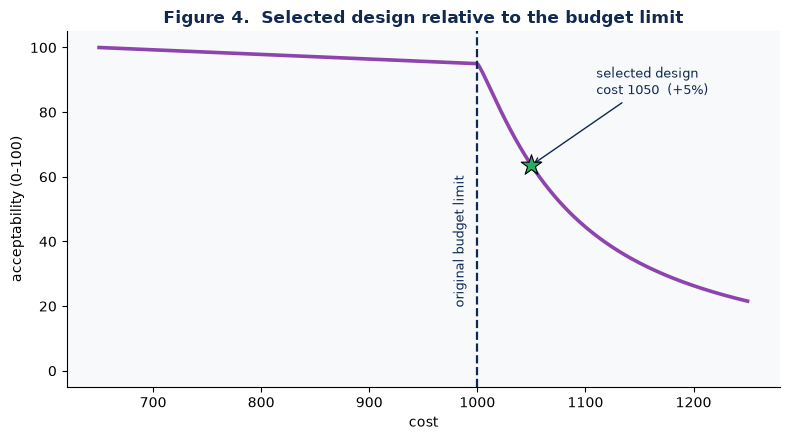

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
cs = np.linspace(COST_LO, COST_HI, 400)
ax.plot(cs, [pref_budget(c) for c in cs], color=PURPLE, lw=2.6)
ax.axvline(COST_CAP, color=NAVY, ls="--", lw=1.6)
ax.scatter([best_cost], [pref_budget(best_cost)], s=240, color=GREEN, marker="*",
           edgecolors="black", linewidths=0.8, zorder=5)
ax.annotate(f"selected design\ncost {best_cost:.0f}  (+{overstep_pct:.0f}%)",
            xy=(best_cost, pref_budget(best_cost)), xytext=(best_cost + 60, pref_budget(best_cost) + 22),
            arrowprops=dict(arrowstyle="->", color=NAVY), color=NAVY, fontsize=9)
ax.text(COST_CAP - 10, 40, "original budget limit", color=NAVY, rotation=90, va="center", ha="right", fontsize=9)
ax.set_xlabel("cost"); ax.set_ylabel("acceptability (0-100)")
ax.set_title("Figure 4.  Selected design relative to the budget limit", fontweight="bold", color=NAVY)
ax.set_ylim(-5, 105); ax.set_facecolor("#f7f9fb")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()



<p><strong>Figure 5.</strong> The full design space with the outcome overlaid. Standard methods returned nothing (the acceptable
region remains empty). By treating the budget as negotiable, IGS-GA-II identifies the lowest-cost certifiable
design, located just beyond the original limit.</p>


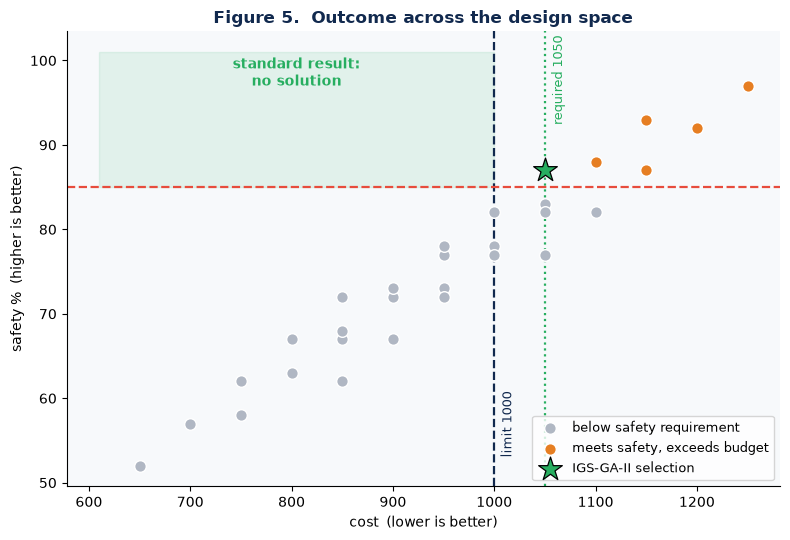

In [12]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ncert = ships[~ships.certifiable]; cert = ships[ships.certifiable]
ax.scatter(ncert.cost, ncert.safety, s=70, color="#b0b7c3", edgecolors="white",
           label="below safety requirement", zorder=3)
ax.scatter(cert.cost,  cert.safety,  s=70, color=ORANGE, edgecolors="white",
           label="meets safety, exceeds budget", zorder=3)
ax.add_patch(plt.Rectangle((COST_LO - 40, SAFETY_MIN), COST_CAP - (COST_LO - 40),
                           SAFE_HI + 4 - SAFETY_MIN, color=GREEN, alpha=0.10, zorder=1))
ax.axvline(COST_CAP, color=NAVY, ls="--", lw=1.6)
ax.axvline(best_cost, color=GREEN, ls=":", lw=1.6)
ax.axhline(SAFETY_MIN, color=RED, ls="--", lw=1.6)
ax.scatter([best_cost], [best_safety], s=320, color=GREEN, marker="*", edgecolors="black",
           linewidths=0.9, zorder=6, label="IGS-GA-II selection")
ax.text(COST_CAP + 6, SAFE_LO + 1, "limit 1000", color=NAVY, fontsize=9, rotation=90, va="bottom")
y_top = ax.get_ylim()[1] - 0.5
ax.text(best_cost + 6, y_top, f"required {best_cost:.0f}",
        color=GREEN, fontsize=9, rotation=90, va="top", ha="left")
ax.text((COST_LO + COST_CAP) / 2 - 20, SAFE_HI + 1.5, "standard result:\nno solution", color=GREEN,
        fontsize=10, ha="center", va="center", fontweight="bold")
ax.set_xlabel("cost  (lower is better)"); ax.set_ylabel("safety %  (higher is better)")
ax.set_title("Figure 5.  Outcome across the design space", fontweight="bold", color=NAVY)
ax.legend(loc="lower right", fontsize=9); ax.set_facecolor("#f7f9fb")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()



<h2 id="Summary">Summary<a class="anchor-link" href="#Summary">¶</a></h2><ul>
<li>A conventional constrained optimiser, faced with two hard requirements that cannot be satisfied
simultaneously, returns no solution and no guidance.</li>
<li>By modelling the budget as a graded preference — high and flat while affordable, a sharp but strictly positive
penalty once exceeded — IGS-GA-II retains a usable signal even when every option breaches the limit.</li>
<li>It converges on the lowest-cost certifiable design and reports the binding constraint together with the minimal
relaxation required: <strong>increase the budget by 5% (1000 → 1050)</strong>, achieved by <strong>engine A, composite hull, and 6
lifeboats</strong>.</li>
</ul>
<p>The approach generalises directly: any hard acceptability limit can be represented this way, converting an
uninformative "infeasible" result into an actionable recommendation that identifies <em>which</em> constraint to relax
and <em>by how much</em>.</p>
